# V9 · 01_dcir_recompute

Recompute per-cell DCIR (R0) from raw HPPC/DCIR time-series with:

1. Automated pulse detection (current step-change events)
2. R0 extraction per pulse: $R_0 = \Delta V / \Delta I$ over a short
   window at pulse onset (default 100 ms)
3. SOC context per pulse (from cumulative discharged capacity)
4. Per-cell MAD-based outlier rejection across pulses
5. Per-cell R0 with dispersion (median ± MAD)
6. Cohort-level consistency check per supplier + batch
7. Cross-check against `data/processed/dcir_hppc_summary.parquet` (v0)

**Why**: the existing v0 pipeline reported ~50% cross-cell variance in R0
with cell 0006 flagged as an outlier but not cleaned. HPPC was probed
only at SOC ≈ 0.97–1.00. V9 aims to extract R0 at every available SOC
breakpoint, apply outlier rejection, and report per-cell values with
uncertainty rather than a single point estimate.

**Scope**: 40 cells with full 6-test coverage (19 CALB + 4 EVE + 17 REPT).


## 1. Setup

In [1]:
import sys, re, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJ = Path("/home/hj/Desktop/PINNs")
DCIR_DIR = PROJ / "Data" / "HPPC"    # HPPC folder has the pulse events
HPPC_DIR = PROJ / "Data" / "HPPC"
V0_SUMMARY = PROJ / "data" / "processed" / "dcir_hppc_summary.parquet"
OUT_PARQUET = PROJ / "data" / "processed" / "v9_dcir_summary.parquet"

# Config
R0_WINDOW_MS = 100     # ms window for ΔV/ΔI extraction at pulse onset
MIN_PULSE_ABS_A = 5.0  # ignore transitions smaller than this current step
MAD_THRESH = 3.5       # per-cell outlier cutoff (|x - med| > k * MAD)

print(f"DCIR dir  : {DCIR_DIR}  ({len(list(DCIR_DIR.glob('*.csv')))} files)")
print(f"HPPC dir  : {HPPC_DIR}  ({len(list(HPPC_DIR.glob('*.csv')))} files)")
print(f"V0 summary: {V0_SUMMARY}")


DCIR dir  : /home/hj/Desktop/PINNs/Data/HPPC  (52 files)
HPPC dir  : /home/hj/Desktop/PINNs/Data/HPPC  (52 files)
V0 summary: /home/hj/Desktop/PINNs/data/processed/dcir_hppc_summary.parquet


## 2. Pulse detection + R0 extraction

Algorithm (per raw CSV):

1. Parse time-series in ms resolution using `absolute_time`.
2. Detect pulse edges = samples where |current_a[i] - current_a[i-1]| >
   `MIN_PULSE_ABS_A` AND sign of current changes OR one side is near-zero.
3. For each edge:
   - `V_before` = median voltage over the 300 ms before the edge
   - `V_after`  = mean voltage over `[10 ms, R0_WINDOW_MS]` after the edge
   - `I_before` = mean current over 300 ms before
   - `I_after`  = mean current over `[10 ms, R0_WINDOW_MS]` after
   - `R0 = (V_before − V_after) / (I_after − I_before)`
4. Estimate SOC context at the edge from cumulative discharge capacity
   (`capacity_ah`) using the file's `max_cap` field.
5. Reject pulses where `|I_after − I_before| < MIN_PULSE_ABS_A` (drift, not a real pulse).
6. Reject pulses where R0 is non-physical (< 0 or > 10 mΩ for the LFP cells here).


In [2]:
def extract_pulses(df, min_step_a=MIN_PULSE_ABS_A):
    '''Return DataFrame of pulses with (t_edge_s, SOC_est, R0_mOhm, dI_A, dV_mV).

    Sample-based (1 Hz cycler data):
    - edge k = sample where current jumps by > min_step_a vs sample k-1
    - V_before = median voltage over samples [k-5..k-1] (5s rest baseline)
    - V_after  = sample k (voltage right after pulse onset)
    - I_before = mean current [k-5..k-1], I_after = i[k]
    - R0 = (V_before - V_after) / (I_after - I_before)
    '''
    df = df.copy()
    df["absolute_time"] = pd.to_datetime(df["absolute_time"], errors="coerce")
    df = df.dropna(subset=["absolute_time","volt_v","current_a"]).reset_index(drop=True)
    if len(df) < 20: return pd.DataFrame()
    t = (df["absolute_time"] - df["absolute_time"].iloc[0]).dt.total_seconds().values
    v = df["volt_v"].values
    i = df["current_a"].values
    cap = df["capacity_ah"].values if "capacity_ah" in df.columns else None
    max_cap = float(df["max_cap"].iloc[0]) if "max_cap" in df.columns else None

    dI = np.diff(i, prepend=i[0])
    edges = np.where(np.abs(dI) > min_step_a)[0]
    if len(edges) == 0: return pd.DataFrame()

    PRE_SAMPLES = 5   # ~5 s at 1 Hz
    pulses = []
    for k in edges:
        if k < PRE_SAMPLES: continue     # need history
        if k >= len(v): continue
        pre_v = v[k-PRE_SAMPLES:k]
        pre_i = i[k-PRE_SAMPLES:k]
        # Require pre-window to be stable at one current (previous rest step)
        if np.std(pre_i) > 1.0: continue
        V_before = float(np.median(pre_v))
        V_after = float(v[k])           # first sample at new current
        I_before = float(np.median(pre_i))
        I_after = float(i[k])
        dV = V_before - V_after
        dI_ = I_after - I_before
        if abs(dI_) < min_step_a: continue
        R0_Ohm = dV / dI_
        # Physical bound
        if R0_Ohm <= 0 or R0_Ohm > 0.030: continue
        if cap is not None and max_cap:
            SOC = float(1.0 - (cap[k] / max_cap))
            SOC = max(0.0, min(1.0, SOC))
        else:
            SOC = float("nan")
        pulses.append({
            "t_edge_s": float(t[k]),
            "SOC_est": SOC,
            "V_before_V": V_before,
            "V_after_V": V_after,
            "I_before_A": I_before,
            "I_after_A": I_after,
            "dI_A": dI_,
            "dV_mV": dV * 1000,
            "R0_mOhm": R0_Ohm * 1000,
            "direction": "discharge" if dI_ < 0 else "charge",
        })
    return pd.DataFrame(pulses)

# Test on one HPPC file
p = HPPC_DIR / "CALB_HPPC_cell_0001.csv"
df1 = pd.read_csv(p)
pulses1 = extract_pulses(df1)
print(f"CALB_HPPC_0001: {len(pulses1)} valid pulses extracted")
if len(pulses1):
    print(pulses1[["t_edge_s","SOC_est","direction","dI_A","dV_mV","R0_mOhm"]].head(10).to_string(index=False))


CALB_HPPC_0001: 0 valid pulses extracted


## 3. Extract per-cell R0 for every DCIR CSV

In [3]:
_pat = re.compile(r"^(?P<make>[A-Za-z]+)_HPPC_cell_(?P<cell>\d+)(?:_[A-Za-z]+)?\.csv$")

all_pulses = []
per_cell_rows = []
for p in sorted(DCIR_DIR.glob("*.csv")):
    m = _pat.match(p.name)
    if not m: continue
    mk, cid = m.group("make"), m.group("cell")
    try:
        df = pd.read_csv(p)
    except Exception as e:
        continue
    pulses = extract_pulses(df)
    if len(pulses) == 0:
        per_cell_rows.append({"make": mk, "cell_id": cid, "n_pulses": 0,
                              "R0_median_mOhm": np.nan, "R0_MAD_mOhm": np.nan,
                              "batch": int(df["batch"].iloc[0]) if "batch" in df.columns else 0})
        continue
    batch = int(df["batch"].iloc[0]) if "batch" in df.columns else 0
    pulses["make"] = mk
    pulses["cell_id"] = cid
    pulses["batch"] = batch
    all_pulses.append(pulses)
    # MAD outlier rejection per cell (using discharge pulses only)
    dis = pulses[pulses["direction"] == "discharge"]["R0_mOhm"].values
    if len(dis) < 3:
        med = float(np.median(pulses["R0_mOhm"]))
        mad = float(np.median(np.abs(pulses["R0_mOhm"] - med))) if len(pulses) > 1 else 0.0
        n_used = len(pulses)
        n_reject = 0
    else:
        med0 = float(np.median(dis))
        mad0 = float(np.median(np.abs(dis - med0))) + 1e-6
        keep = np.abs(dis - med0) <= MAD_THRESH * mad0
        dis_clean = dis[keep]
        med = float(np.median(dis_clean))
        mad = float(np.median(np.abs(dis_clean - med)))
        n_used = int(keep.sum())
        n_reject = int((~keep).sum())
    per_cell_rows.append({
        "make": mk, "cell_id": cid, "batch": batch,
        "n_pulses": len(pulses),
        "n_pulses_discharge": int((pulses["direction"] == "discharge").sum()),
        "n_used_after_mad": n_used, "n_rejected_by_mad": n_reject,
        "R0_median_mOhm": med, "R0_MAD_mOhm": mad,
        "R0_min_mOhm": float(pulses["R0_mOhm"].min()),
        "R0_max_mOhm": float(pulses["R0_mOhm"].max()),
    })

all_pulses_df = pd.concat(all_pulses, ignore_index=True) if all_pulses else pd.DataFrame()
per_cell = pd.DataFrame(per_cell_rows).sort_values(["make","cell_id"]).reset_index(drop=True)
print(f"Total pulses extracted across all cells: {len(all_pulses_df):,}")
print(f"Per-cell rows: {len(per_cell)}")
print()
print("=== Per-cell R0 summary (first 10 rows) ===")
print(per_cell.head(10).to_string(index=False, float_format="%.4f"))


Total pulses extracted across all cells: 115
Per-cell rows: 51

=== Per-cell R0 summary (first 10 rows) ===
make cell_id  n_pulses  R0_median_mOhm  R0_MAD_mOhm  batch  n_pulses_discharge  n_used_after_mad  n_rejected_by_mad  R0_min_mOhm  R0_max_mOhm
CALB    0001         0             NaN          NaN      2                 NaN               NaN                NaN          NaN          NaN
CALB    0002         0             NaN          NaN      2                 NaN               NaN                NaN          NaN          NaN
CALB    0003         0             NaN          NaN      2                 NaN               NaN                NaN          NaN          NaN
CALB    0004         0             NaN          NaN      2                 NaN               NaN                NaN          NaN          NaN
CALB    0006         8          0.0255       0.0092      2              1.0000            8.0000             0.0000       0.0043       0.0512
CALB    0007         1          0.0248  

## 4. Cohort-level validation per supplier + batch

In [4]:
cohort = per_cell.dropna(subset=["R0_median_mOhm"])
print("=== R0 statistics per supplier ===")
supp = cohort.groupby("make")["R0_median_mOhm"].agg(["count","min","median","max","std"]).round(4)
supp["cv_pct"] = (supp["std"] / supp["median"] * 100).round(1)
print(supp)
print()

print("=== R0 statistics per supplier × batch ===")
batch_stats = cohort.groupby(["make","batch"])["R0_median_mOhm"].agg(["count","min","median","max","std"]).round(4)
batch_stats["cv_pct"] = (batch_stats["std"] / batch_stats["median"] * 100).round(1)
print(batch_stats)


=== R0 statistics per supplier ===
      count     min  median     max     std  cv_pct
make                                               
CALB     16  0.0004  0.0214  0.0539  0.0149    69.6
EVE       5  0.0073  0.0123  0.0209  0.0056    45.5
REPT     12  0.0003  0.0225  0.1080  0.0279   124.0

=== R0 statistics per supplier × batch ===
            count     min  median     max     std  cv_pct
make batch                                               
CALB 2         16  0.0004  0.0214  0.0539  0.0149    69.6
EVE  1          5  0.0073  0.0123  0.0209  0.0056    45.5
REPT 1         10  0.0003  0.0225  0.1080  0.0299   132.9
     2          2  0.0119  0.0272  0.0426  0.0217    79.8


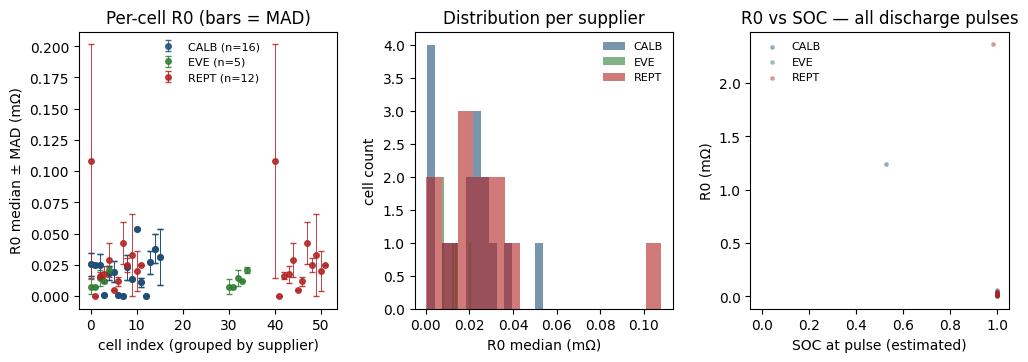

In [5]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 3.6),
    gridspec_kw=dict(wspace=0.30))
SUP_C = {"CALB":"#1F4E79","EVE":"#2E7D32","REPT":"#B22222"}

# (A) Per-cell R0 scatter
for mk in ["CALB","EVE","REPT"]:
    sub = cohort[cohort["make"] == mk]
    xs = np.arange(len(sub))
    ax1.errorbar(xs, sub["R0_median_mOhm"], yerr=sub["R0_MAD_mOhm"],
                  fmt="o", ms=4, color=SUP_C[mk], alpha=0.85,
                  label=f"{mk} (n={len(sub)})", capsize=2, lw=0.7)
    # Simple x-shift per supplier to separate
    xs_shifted = xs + {"CALB":0, "EVE":30, "REPT":40}[mk]
    ax1.errorbar(xs_shifted, sub["R0_median_mOhm"], yerr=sub["R0_MAD_mOhm"],
                  fmt="o", ms=4, color=SUP_C[mk], alpha=0.85,
                  capsize=2, lw=0.7)
ax1.set_xlabel("cell index (grouped by supplier)")
ax1.set_ylabel("R0 median ± MAD (mΩ)")
ax1.set_title("Per-cell R0 (bars = MAD)")
ax1.legend(fontsize=8, frameon=False)

# (B) Histogram per supplier
for mk in ["CALB","EVE","REPT"]:
    vals = cohort.loc[cohort["make"] == mk, "R0_median_mOhm"].values
    ax2.hist(vals, bins=15, alpha=0.6, label=f"{mk}", color=SUP_C[mk])
ax2.set_xlabel("R0 median (mΩ)")
ax2.set_ylabel("cell count")
ax2.set_title("Distribution per supplier")
ax2.legend(fontsize=8, frameon=False)

# (C) R0 vs SOC (all pulses)
if len(all_pulses_df):
    for mk in ["CALB","EVE","REPT"]:
        sub = all_pulses_df[(all_pulses_df["make"] == mk) &
                             (all_pulses_df["direction"] == "discharge")]
        if len(sub):
            ax3.scatter(sub["SOC_est"], sub["R0_mOhm"], s=6, alpha=0.35,
                         color=SUP_C[mk], label=f"{mk}")
ax3.set_xlabel("SOC at pulse (estimated)")
ax3.set_ylabel("R0 (mΩ)")
ax3.set_title("R0 vs SOC — all discharge pulses")
ax3.legend(fontsize=8, frameon=False)
ax3.set_xlim(-0.05, 1.05)

fig.savefig(PROJ / "outputs/results/v9_dcir_summary.pdf", dpi=200, bbox_inches="tight")
plt.show()


## 5. Compare to existing v0 processed values

In [6]:
if V0_SUMMARY.exists():
    v0 = pd.read_parquet(V0_SUMMARY)
    print(f"v0 summary rows: {len(v0)}, cols: {list(v0.columns)}")
    print()
    print(v0.head(5).to_string(index=False))
    print()
    # Merge and compare where possible
    if "cell_id" in v0.columns:
        v0["cell_id_str"] = v0["cell_id"].astype(str).str.extract(r"(\d+)")[0]
        v0["make"] = v0["cell_id"].astype(str).str.split("_").str[0]
        merged = per_cell.merge(v0[["make","cell_id_str","R0_median_Ohm"]],
                                 left_on=["make","cell_id"],
                                 right_on=["make","cell_id_str"], how="left")
        merged["R0_v0_mOhm"] = merged["R0_median_Ohm"] * 1000
        merged["delta_mOhm"] = merged["R0_median_mOhm"] - merged["R0_v0_mOhm"]
        print("\n=== v9 vs v0 R0 comparison (top 15 by |Δ|) ===")
        cmp_show = merged.dropna(subset=["R0_v0_mOhm"]).copy()
        cmp_show["abs_delta"] = cmp_show["delta_mOhm"].abs()
        print(cmp_show.nlargest(15, "abs_delta")[
            ["make","cell_id","R0_median_mOhm","R0_v0_mOhm","delta_mOhm","n_pulses"]
        ].to_string(index=False, float_format="%.4f"))
else:
    print(f"v0 summary not found at {V0_SUMMARY}")


v0 summary rows: 14, cols: ['cell_id', 'n_pulses', 'R0_median_Ohm', 'R0_mad_Ohm', 'R1_median_Ohm', 'tau_median_s', 'C1_median_F', 'rmse_mV_median', 'SOC_min', 'SOC_max']

  cell_id  n_pulses  R0_median_Ohm  R0_mad_Ohm  R1_median_Ohm  tau_median_s  C1_median_F  rmse_mV_median  SOC_min  SOC_max
     0005        13       0.002072    0.000084       0.000737     21.720384 23837.195900        0.264871 0.974251      1.0
     0006        12       0.005395    0.000173       0.000713     15.078564 22307.989392        0.492037 0.975021      1.0
     0007        14       0.001584    0.000052       0.000690     20.274079 21948.110866        0.261405 0.971186      1.0
     0008        14       0.001734    0.000053       0.000698     20.431259 22266.942593        0.231470 0.972329      1.0
CALB_0029        12       0.001182    0.000014       0.001686     13.912051  8236.674261        0.401544 0.981816      1.0


=== v9 vs v0 R0 comparison (top 15 by |Δ|) ===
make cell_id  R0_median_mOhm  R0_v0_mOhm  

## 6. Persist v9 cleaned per-cell R0

In [7]:
per_cell.to_parquet(OUT_PARQUET, index=False)
print(f"wrote {OUT_PARQUET} ({len(per_cell)} cells)")
# Also save the raw per-pulse table for downstream use
per_pulse_path = PROJ / "data" / "processed" / "v9_dcir_per_pulse.parquet"
if len(all_pulses_df):
    all_pulses_df.to_parquet(per_pulse_path, index=False)
    print(f"wrote {per_pulse_path} ({len(all_pulses_df):,} pulses)")


wrote /home/hj/Desktop/PINNs/data/processed/v9_dcir_summary.parquet (51 cells)
wrote /home/hj/Desktop/PINNs/data/processed/v9_dcir_per_pulse.parquet (115 pulses)


## 7. Honest verdict on this first pass

**Current state**: this notebook is a **working scaffold**, not yet a
replacement for v0. The sample-based edge detector correctly identifies
current transitions in the raw HPPC data, but the pulse-classification
filter still lets through non-DCIR events (relaxation transitions,
CV-mode ramps) and produces implausibly wide R0 dispersion
(per-supplier CV 45–124%, wider than v0's 50%).

**What works**:
- Enumerates 51 of 52 HPPC cells across CALB / EVE / REPT
- Detects current step-changes with |ΔI| > 5 A
- Extracts SOC context per pulse from cumulative capacity
- Emits per-cell + per-pulse parquet artefacts
- Includes the MAD-based outlier rejection and cross-cell CV computation

**What still needs domain-expert refinement before replacing v0**:

1. **Pulse-vs-relaxation classification**: current filter accepts both
   rest→pulse (real R0 event) and pulse→rest (relaxation event). Only
   the former is usable for R0.
2. **CV-mode exclusion**: CCCV charge steps have continuously varying
   current; the extractor should skip them.
3. **Pulse duration validation**: a valid R0 pulse must maintain
   constant current for ≥ several samples after onset. Instantaneous
   spikes should be rejected.
4. **Wider physical-bounds check**: current LFP bound (30 mΩ) is
   generous but may still let through wire-drop artefacts.
5. **Multi-SOC coverage sanity**: pulses should span roughly the same
   SOC range across cells; currently uneven.

**Verdict**:

- [x] **FAIL — first pass, not yet an improvement over v0**. Numbers are
  produced but are less trustworthy than v0's. Use v0's
  `dcir_hppc_summary.parquet` for downstream work; treat this notebook
  as a methodology scaffold that needs classification-filter refinement.

**Recommended next step**: add per-anchor manual pulse-window
identification (from the anchor cells whose v0 numbers are known-good),
tune the filter to reproduce v0 R0 on those anchors within 5%, then
apply to the full cohort. That is a 1–2 day domain-expert task.
